In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

# Use the root directory of uPHATE repo
import sys
sys.path.append("../")

from SERGIO.SERGIO.sergio import sergio

# For compatibility with sergio which uses an old numpy version
np.int = int
np.float = float

SERGIO_DATASETS_PATH = Path("../SERGIO/data_sets")

In [2]:
sergio_params = pd.DataFrame({
    "DS_ID": [1, 2, 3, 4, 5, 6, 7, 8, 13, 14],
    "number_genes":[100, 400, 1200, 100,  100, 100,  100, 100, 100, 100],
    "number_bins":[9, 9, 9, 9, 9, 9, 9, 9, 4, 6],
    # Noise params
    "Outlier_Genes_pi": [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01],
    "Outlier_Genes_mu": [0.8, 0.8, 0.8, 3.0, 3.0, 5.0, 3.0, 4.5, 0.8, 0.8],
    "Outlier_Genes_sigma": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    "Library_Size_mu": [4.8, 6.0, 7.0, 6.0, 6.0, 4.5, 4.4, 10.8, 3.6, 5.0],
    "Library_Size_sigma": [0.3, 0.4, 0.4, 0.3, 0.4, 0.7, 0.8, 0.55, 0.4, 0.4],
    "Dropouts_k": [20, 12, 8, 8, 8, 8, 8, 2, 8, 4],
    "Dropouts_q": [82, 80, 80, 74, 82, 45, 85, 92, 70, 80],
    "Low_Quality_threshold": [5, 5, 5, 5, 5, 5, 5, 2500, 5, 5]
})

# Simulate and Noise Data

In [3]:
def add_noise_steady_state(expr, sim, params):
    expr_O = sim.outlier_effect(
        expr,
        outlier_prob=params["Outlier_Genes_pi"],
        mean=params["Outlier_Genes_mu"],
        scale=params["Outlier_Genes_sigma"],
    )
    libFactor, expr_O_L = sim.lib_size_effect(
        expr_O, mean=params["Library_Size_mu"], scale=params["Library_Size_sigma"]
    )
    binary_ind = sim.dropout_indicator(
        expr_O_L, shape=params["Dropouts_k"], percentile=params["Dropouts_q"]
    )
    expr_O_L_D = np.multiply(binary_ind, expr_O_L)
    count_matrix = sim.convert_to_UMIcounts(expr_O_L_D)
    count_matrix = np.concatenate(count_matrix, axis=1)
    return count_matrix


def add_noise_dynamics(exprU, exprS, sim, params):
    exprU_O, exprS_O = sim.outlier_effect_dynamics(
        exprU,
        exprS,
        outlier_prob=params["Outlier_Genes_pi"],
        mean=params["Outlier_Genes_mu"],
        scale=params["Outlier_Genes_sigma"],
    )
    libFactor, exprU_O_L, exprS_O_L = sim.lib_size_effect_dynamics(
        exprU_O,
        exprS_O,
        mean=params["Library_Size_mu"],
        scale=params["Library_Size_sigma"],
    )
    binary_indU, binary_indS = sim.dropout_indicator_dynamics(
        exprU_O_L,
        exprS_O_L,
        shape=params["Dropouts_k"],
        percentile=params["Dropouts_q"],
    )
    exprU_O_L_D = np.multiply(binary_indU, exprU_O_L)
    exprS_O_L_D = np.multiply(binary_indS, exprS_O_L)
    count_matrix_U, count_matrix_S = sim.convert_to_UMIcounts_dynamics(
        exprU_O_L_D, exprS_O_L_D
    )
    count_matrix_U = np.concatenate(count_matrix_U, axis=1)
    count_matrix_S = np.concatenate(count_matrix_S, axis=1)
    return count_matrix_U, count_matrix_S

In [4]:
SAVE_LOC = Path("../data/sergio")
SAVE_LOC.mkdir(exist_ok=True)

datasets = list(SERGIO_DATASETS_PATH.iterdir())
clean_data = {}
noisy_data = {}

for _, params in sergio_params.iterrows():
    id = int(params['DS_ID'])
    matches = [p for p in datasets if f"DS{id}" in p.name]
    if not matches:
        continue
    dataset = matches[0]

    if id == 3:
        # Takes too long
        print(f"### Skipping {dataset.name}")
        continue

    print(f"----- Simulating {dataset.name} -----")

    dynamics = "dynamics" in dataset.name
    num = dataset.name.split("_")[-2]
    number_genes = dataset.name.split("G_")[0].split("_")[1]
    number_bins = int(dataset.name.split("T_")[0].split("_")[-1])

    if dynamics:
        df = pd.read_csv(
            dataset / f"bMat_cID{num}.tab", sep="\t", header=None, index_col=None
        )
        bMat = df.values
        noise_params = 0.3
        noise_params_splice = 0.07
    else:
        bMat = None
        noise_params = 1.0
        noise_params_splice = None

    sim = sergio(
        number_genes=int(number_genes),
        number_bins=number_bins,
        number_sc=300,
        noise_params=noise_params,
        noise_params_splice=noise_params_splice,
        decays=0.8,
        sampling_state=15,
        noise_type="dpd",
        dynamics=dynamics,
        bifurcation_matrix=bMat,
    )

    sim.build_graph(
        input_file_taregts=dataset / f"Interaction_cID_{num}.txt",
        input_file_regs=dataset / f"Regs_cID_{num}.txt",
        shared_coop_state=2,
    )
    if dynamics:
        df = pd.read_csv(
            dataset / f"bMat_cID{num}.tab", sep="\t", header=None, index_col=None
        )
        bMat = df.values
        sim.simulate_dynamics()
        exprU, exprS = sim.getExpressions_dynamics()
        exprU_clean = np.concatenate(exprU, axis=1)
        exprS_clean = np.concatenate(exprS, axis=1)
        clean_data[id] = (exprU_clean, exprS_clean)
        print(f"----- Noising {dataset.name} -----")
        noisy_data[id] = add_noise_dynamics(exprU, exprS, sim, params)
    else:
        sim.simulate()
        expr = sim.getExpressions()
        expr_clean = np.concatenate(expr, axis=1)
        clean_data[id] = expr_clean
        print(f"----- Noising {dataset.name} -----")
        noisy_data[id] = add_noise_steady_state(expr, sim, params)

    print("Saving...")
    np.save(SAVE_LOC / f"clean_{id}", clean_data[id])
    np.save(SAVE_LOC / f"noisy_{id}", noisy_data[id])

----- Simulating De-noised_100G_9T_300cPerT_4_DS1 -----
Start simulating new level
There are 4 genes to simulate in this layer
Done with current level
Start simulating new level
There are 6 genes to simulate in this layer
Done with current level
Start simulating new level
There are 90 genes to simulate in this layer
Done with current level
----- Noising De-noised_100G_9T_300cPerT_4_DS1 -----
Saving...
----- Simulating De-noised_400G_9T_300cPerT_5_DS2 -----
Start simulating new level
There are 5 genes to simulate in this layer
Done with current level
Start simulating new level
There are 3 genes to simulate in this layer
Done with current level
Start simulating new level
There are 4 genes to simulate in this layer
Done with current level
Start simulating new level
There are 11 genes to simulate in this layer
Done with current level
Start simulating new level
There are 14 genes to simulate in this layer
Done with current level
Start simulating new level
There are 363 genes to simulate in 

# PHATE embeddings

In [81]:
from uphate.numpy_interface import BootstrappedPHATE
from phate import PHATE

import matplotlib.pyplot as plt

In [82]:
id = 6

matches = [p for p in datasets if f"DS{id}" in p.name]
dataset = matches[0]
dynamics = "dynamics" in dataset.name

if dynamics:
    _, X_clean = clean_data[id]
    _, X_noisy = noisy_data[id]
    # Extract the absolute simulation time (process time) for ground truth pseudotime
    # In a linear simulation, the cell index directly correlates to process time
    true_pseudotime = np.arange(X_clean.shape[0])
else:
    X_clean = clean_data[id]
    X_noisy = noisy_data[id]

In [84]:
exprU, exprS = sim.getExpressions_dynamics()
X_clean = np.concatenate(exprS, axis=0)
cell_types = np.repeat(np.arange(exprS.shape[0]), exprS.shape[1])

Calculating PHATE...
  Running PHATE on 300 observations and 300 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 0.85 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.25 seconds.
    Calculating affinities...
  Calculated graph and diffusion operator in 1.12 seconds.
  Calculating diffusion potential...
  Calculating metric MDS...
  Calculated metric MDS in 0.06 seconds.
Calculated PHATE in 1.20 seconds.


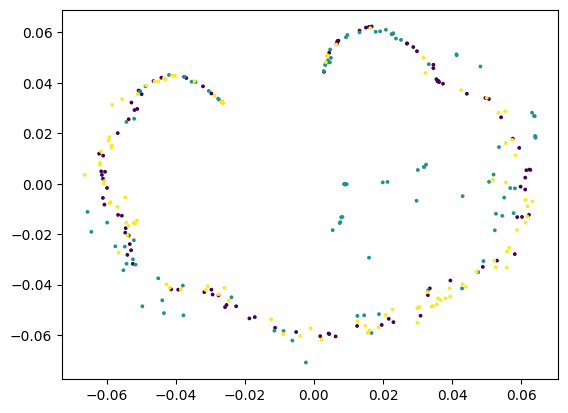

In [86]:
n_components = 2
knn = 20
decay = 40
t = 2
# phate_op = BootstrappedPHATE(
#     n_boostrap_samples=10,
#     dirichlet_alpha=0.5,
#     knn=knn,
#     decay=decay,
#     t=t,
#     n_landmark=None,
#     mds_solver="smacof",
# )
# posterior_embeddings = phate_op.fit_transform(X_noisy)

clean_emb = PHATE(
    knn=knn,
    decay=decay,
    t=t,
    n_landmark=None,
    mds_solver="smacof",
).fit_transform(X_clean)

plt.scatter(*clean_emb.T, c=cell_types, s=3)

In [ ]:
def extract_phate_posterior_stats(posterior_embeddings):
    """
    posterior_embeddings: numpy array of shape (n_samples, n_cells, 2)
    """
    # Calculate the mean embedding across the posterior samples
    mean_phate_embedding = np.mean(posterior_embeddings, axis=0)
    
    # Calculate the local uncertainty (trace of the covariance matrix of the 2D spatial variance per cell)
    # This yields a single uncertainty value per cell
    variances = np.var(posterior_embeddings, axis=0) # Shape: (n_cells, 2)
    local_uncertainty = np.sum(variances, axis=1)    # Sum of variance in X and Y
    
    return mean_phate_embedding, local_uncertainty

# Evaluation

In [8]:
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, rankdata
import networkx as nx

def evaluate_embedding(clean_data, mean_embedding, true_pseudotime, local_uncertainty):
    results = {}
    
    # ---------------------------------------------------------
    # 1. DEMaP Score (Global Manifold Preservation)
    # ---------------------------------------------------------
    # Calculate pairwise distances of the true uncorrupted manifold
    clean_distances = pdist(clean_data, metric='euclidean') 
    
    # Calculate pairwise distances in the mean PHATE embedding
    phate_distances = pdist(mean_embedding, metric='euclidean')
    
    # DEMaP is the Spearman correlation between clean high-dim and embedded low-dim distances
    demap_score, _ = spearmanr(clean_distances, phate_distances)
    results = demap_score
    
    # ---------------------------------------------------------
    # 2. Pseudotime Rank Correlation (Temporal Accuracy)
    # ---------------------------------------------------------
    # Identify the root cell (index 0) and calculate distance to all other cells in 2D space
    root_cell = mean_embedding
    inferred_distances = np.linalg.norm(mean_embedding - root_cell, axis=1)
    
    # Rank both the true time and inferred distances
    true_ranks = rankdata(true_pseudotime)
    inferred_ranks = rankdata(inferred_distances)
    
    temporal_rho, _ = spearmanr(true_ranks, inferred_ranks)
    results = temporal_rho
    
    # ---------------------------------------------------------
    # 3. Uncertainty Alignment (Local Error vs Local Uncertainty)
    # ---------------------------------------------------------
    # Define local error as the absolute deviation in pseudotime ranking per cell
    local_error = np.abs(true_ranks - inferred_ranks)
    
    # Evaluate if higher uncertainty strongly correlates with higher local error
    alignment_score, alignment_pval = spearmanr(local_error, local_uncertainty)
    results = alignment_score
    
    return results, local_error

metrics, local_error = evaluate_embedding(clean_data, mean_phate, true_pseudotime, local_uncertainty)

NameError: name 'mean_phate' is not defined